In [4]:
import pandas as pd

In [5]:
import os
os.listdir()

['.ipynb_checkpoints', 'data.csv', 'House_price_Prediction.ipynb']

In [6]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [7]:
print("Rows and columns:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (4600, 18)

Missing values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [8]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [9]:
X = df.drop(columns=[
    "price",
    "date",
    "street",
    "city",
    "statezip",
    "country"
])

y = df["price"]

print(X.shape)
print(y.shape)

(4600, 12)
(4600,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3680, 12)
Testing data: (920, 12)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 304863.3857807   326517.06991507 1071762.53630098  546241.40097356
  379799.9832109 ]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 210908.1732501095
RMSE: 993439.3625461609
R² Score: 0.03228385663277933


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [16]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 208107.66485442096
Random Forest MSE: 991778248188.961
Random Forest RMSE: 995880.6395291361
Random Forest R² Score: 0.027521883243313394


In [17]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [18]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R² Score:", dt_r2)

Decision Tree MAE: 262910.0164926837
Decision Tree MSE: 1052121827350.4335
Decision Tree RMSE: 1025729.8998032735
Decision Tree R² Score: -0.03164740215739448


In [20]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [21]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R² Score:", lr_r2)

Linear Regression MAE: 210908.1732501095
Linear Regression MSE: 986921767056.1227
Linear Regression RMSE: 993439.3625461609
Linear Regression R² Score: 0.03228385663277933


In [22]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "MSE": [lr_mse, dt_mse, rf_mse],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R² Score": [lr_r2, dt_r2, rf_r2]
})

model_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,210908.173250,9.869218e+11,9.934394e+05,0.032284
1,Decision Tree,262910.016493,1.052122e+12,1.025730e+06,-0.031647
2,Random Forest,208107.664854,9.917782e+11,9.958806e+05,0.027522


In [24]:
import matplotlib.pyplot as plt

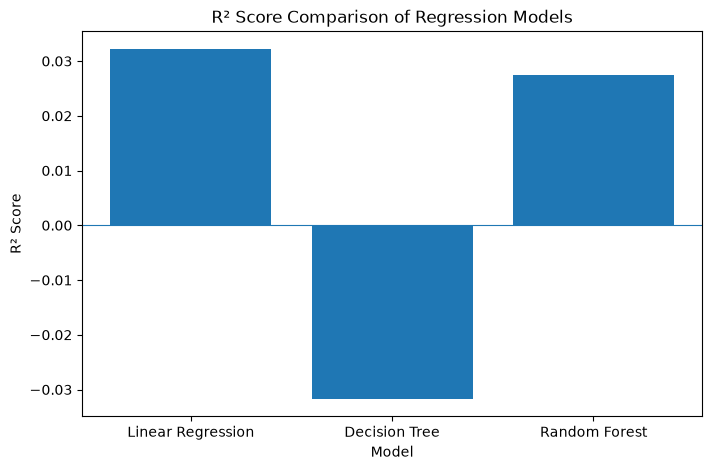

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(model_comparison["Model"], model_comparison["R² Score"])

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.axhline(0, linewidth=0.8)

plt.show()

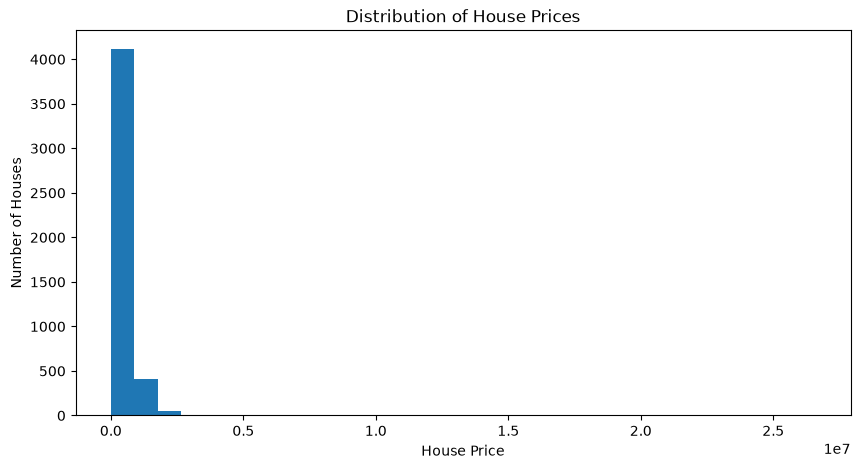

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(y, bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")

plt.show()

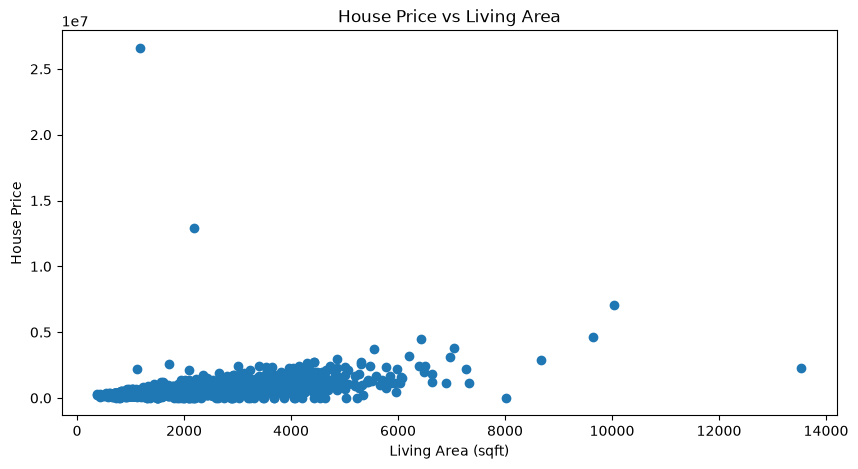

In [27]:
plt.figure(figsize=(10, 5))

plt.scatter(X["sqft_living"], y)

plt.title("House Price vs Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

In [32]:
import sys
!{sys.executable} -m pip install seaborn

In [33]:
import seaborn as sns
print("Seaborn installed successfully!")

Seaborn installed successfully!


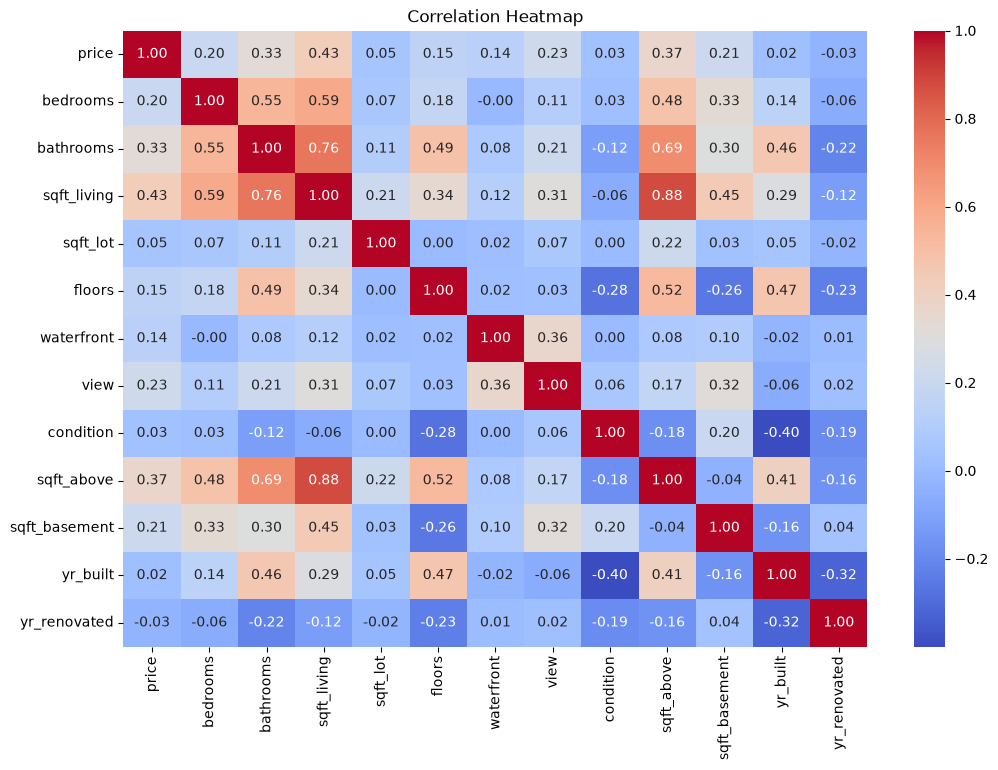

In [34]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

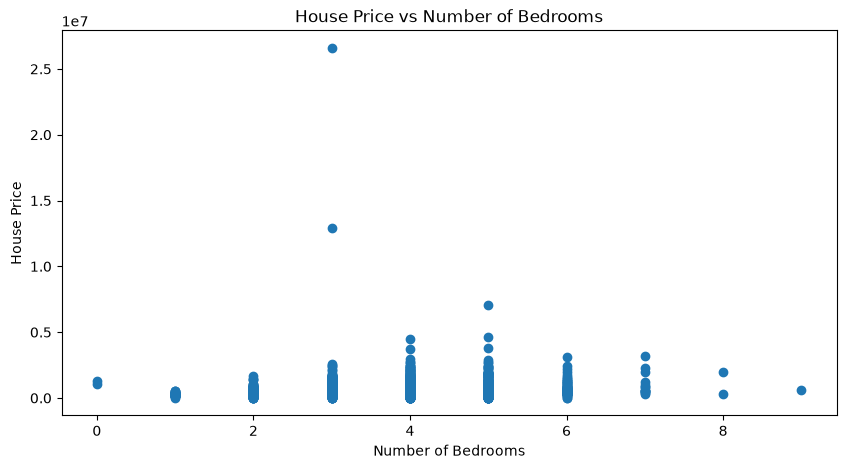

In [35]:
plt.figure(figsize=(10, 5))

plt.scatter(df["bedrooms"], df["price"])

plt.title("House Price vs Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price")

plt.show()

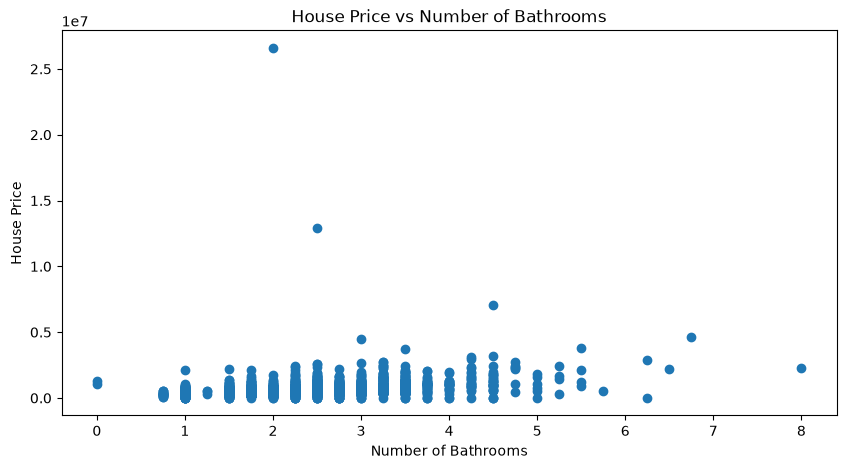

In [36]:
plt.figure(figsize=(10, 5))

plt.scatter(df["bathrooms"], df["price"])

plt.title("House Price vs Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("House Price")

plt.show()

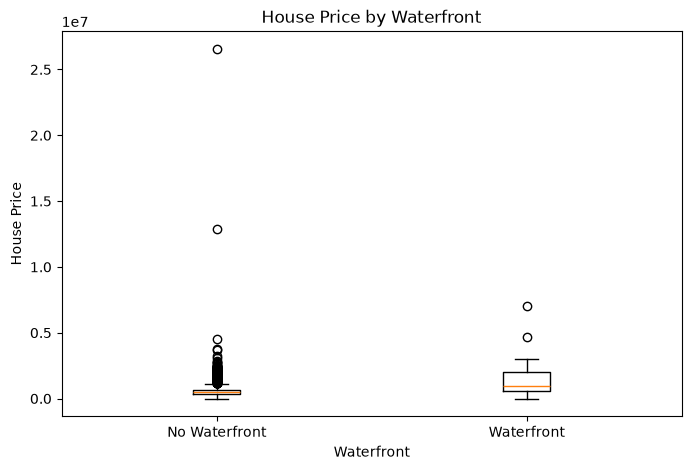

In [38]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df[df["waterfront"] == 0]["price"],
     df[df["waterfront"] == 1]["price"]],
    tick_labels=["No Waterfront", "Waterfront"]
)

plt.title("House Price by Waterfront")
plt.xlabel("Waterfront")
plt.ylabel("House Price")

plt.show()

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

sqft_living      0.542487
yr_built         0.095895
sqft_lot         0.085278
sqft_above       0.069310
sqft_basement    0.049587
bathrooms        0.045838
view             0.032004
yr_renovated     0.020190
bedrooms         0.019711
condition        0.018310
floors           0.013183
waterfront       0.008207
dtype: float64


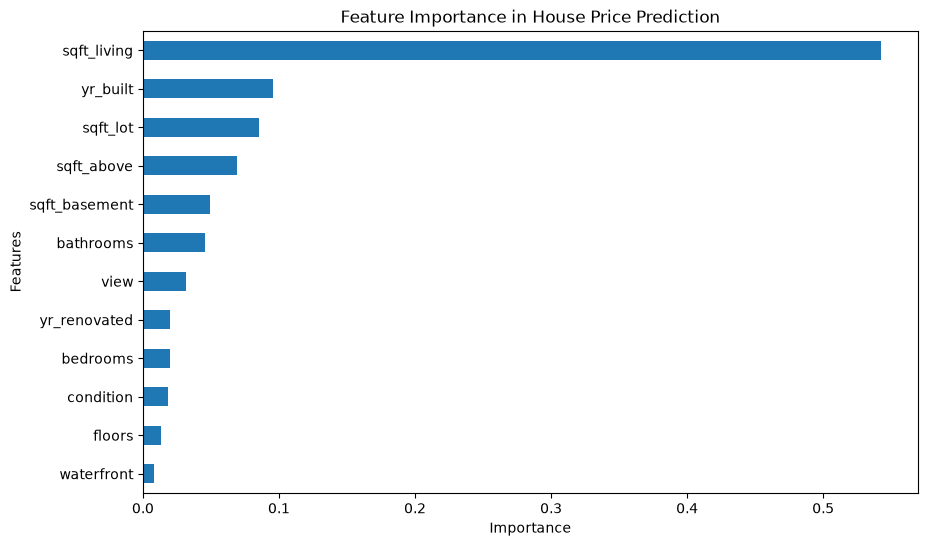

In [40]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance in House Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [41]:
improved_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

improved_rf.fit(X_train, y_train)

improved_rf_pred = improved_rf.predict(X_test)

print("Improved Random Forest trained successfully!")

Improved Random Forest trained successfully!


In [42]:
improved_rf_mae = mean_absolute_error(y_test, improved_rf_pred)
improved_rf_mse = mean_squared_error(y_test, improved_rf_pred)
improved_rf_rmse = np.sqrt(improved_rf_mse)
improved_rf_r2 = r2_score(y_test, improved_rf_pred)

print("Improved Random Forest MAE:", improved_rf_mae)
print("Improved Random Forest MSE:", improved_rf_mse)
print("Improved Random Forest RMSE:", improved_rf_rmse)
print("Improved Random Forest R² Score:", improved_rf_r2)

Improved Random Forest MAE: 205171.01427284296
Improved Random Forest MSE: 988008460010.4121
Improved Random Forest RMSE: 993986.1467899902
Improved Random Forest R² Score: 0.03121831086223048


In [43]:
sample_predictions = pd.DataFrame({
    "Actual Price": y_test.iloc[:10].values,
    "Predicted Price": improved_rf_pred[:10]
})

sample_predictions

,Actual Price,Predicted Price
0,5.440000e+05,4.023167e+05
1,0.000000e+00,3.572981e+05
2,1.712500e+06,1.074180e+06
3,3.650000e+05,5.017668e+05
4,2.750000e+05,3.096179e+05
5,6.250000e+05,5.596792e+05
6,4.530000e+05,4.569301e+05
7,3.000000e+05,3.515670e+05
8,4.179857e+05,3.601984e+05
9,6.725000e+05,5.906963e+05


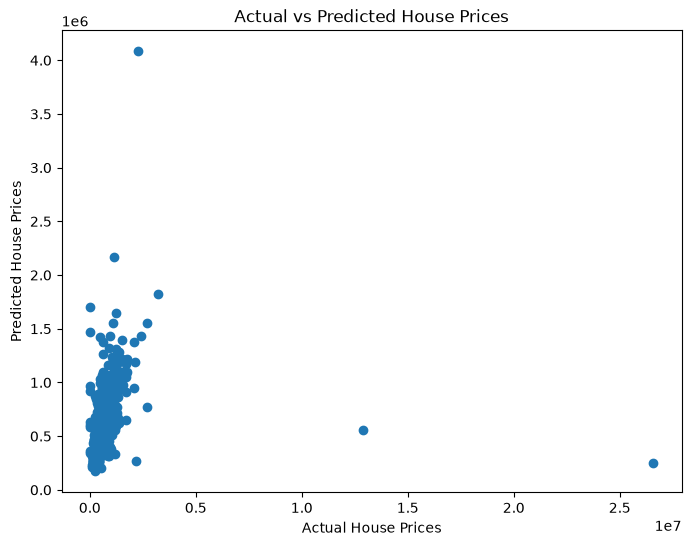

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, improved_rf_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [45]:
print(X_train.columns.tolist())

['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


In [ ]:
sample_houses = pd.DataFrame({
    "bedrooms": [3, 4, 5],
    "bathrooms": [2, 2.5, 3],
    "sqft_living": [1500, 2200, 3000],
    "sqft_lot": [5000, 7500, 10000],
    "floors": [1, 2, 2],
    "waterfront": [0, 0, 1],
    "view": [0, 1, 2],
    "condition": [3, 3, 4],
    "sqft_above": [1500, 1800, 2400],
    "sqft_basement": [0, 400, 600],
    "yr_built": [1995, 2005, 2015],
    "yr_renovated": [0, 0, 2020]
})

sample_houses["Predicted Price"] = improved_rf.predict(sample_houses)

sample_houses

## Final Model Performance

Three regression models were trained and evaluated for house price prediction: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

After comparing the models, the Random Forest model was further improved using hyperparameter tuning.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 210908.17 | 993439.36 | 0.0323 |
| Decision Tree | 262910.02 | 1025729.90 | -0.0316 |
| Random Forest | 208107.66 | 995880.64 | 0.0275 |
| Improved Random Forest | 205171.01 | 993986.15 | 0.0312 |

The Improved Random Forest achieved the lowest MAE among the tested models. It also improved the MAE, RMSE, MSE, and R² compared with the original Random Forest model.

## Feature Importance Analysis

Feature importance from the Random Forest model showed that `sqft_living` was the most important feature for predicting house prices, with an importance of approximately 0.54.

Other relatively important features were `yr_built`, `sqft_lot`, `sqft_above`, `sqft_basement`, and `bathrooms`.

This indicates that the size of the living area has a strong influence on house price predictions in this dataset.

## Sample House Price Predictions

The final Improved Random Forest model was also used to predict prices for three hypothetical houses.

| House | Predicted Price |
|---|---:|
| House 1 | 404870.18 |
| House 2 | 443150.47 |
| House 3 | 884547.41 |

The predictions demonstrate how the trained model can be used to estimate house prices for new properties based on their features.

## Conclusion

In this project, machine learning techniques were used to predict house prices using the HouseData dataset. The dataset was inspected and analyzed through data cleaning, exploratory data analysis, and visualization.

Three regression models were developed: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The models were evaluated using MAE, MSE, RMSE, and R² Score. Among the original models, Linear Regression achieved the highest R² score, while Random Forest achieved a lower MAE.

The Random Forest model was further improved using hyperparameter tuning. The Improved Random Forest achieved an MAE of approximately 205171 and an R² score of 0.0312. Feature importance analysis showed that `sqft_living` was the most influential feature in the model.

Although the final model showed improvement, the relatively low R² score indicates that the current features and models do not explain all the variation in house prices. Overall, the project provided practical experience in data preprocessing, visualization, regression modeling, model evaluation, feature analysis, and prediction.